# Workshop — Comparing Classifiers

___________________

## Learning objectives:

- Train and evaluate multiple classifiers on the same dataset.

- Use ROC–AUC and 10-fold cross-validation for fair comparison.

- Perform a paired t-test to see if differences in performance are statistically significant.

- Interpret and discuss results critically.

___________________

## Part 0 — Setup

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# We'll use the Penguins dataset from seaborn (slightly cleaner than Iris)
penguins = sns.load_dataset("penguins").dropna()
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


## Part 1 — Preprocessing

In [7]:
# Encode categorical features
from sklearn.preprocessing import LabelEncoder

df = penguins.copy()
for col in ["species", "island", "sex"]:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop(columns=["species"])
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

**Exercises**

(If you don't know the answer, do some research, and play around with the code. This might help you get to the right answer.)

1. What is the target variable here?

2. Why should we bother setting `random_state` to a value?

3. Why do we use `stratify=y` when splitting? What does that do?

4. Why do we encode categorical columns before training?

## Part 2 — Try multiple classifiers

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM (RBF kernel)": SVC(probability=True, random_state=42)
}

Read the cell above. There, we are importing four different classifiers, and storing them in a `dictionary` we called `models`.

This way, regardless of whether say `m = models["Logistic Regression"]` or `m = models["SVM (RBF kernel)"]`, the variable `m` represents a classifier from sklearn.

## Part 3 — Evaluate with ROC and AUC

In [8]:
from sklearn.metrics import roc_auc_score
import numpy as np

for name, model in models.items():
    
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)

    # For multiclass, use 'ovr' average
    auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
    
    print(f"{name:20s} | ROC-AUC: {auc:.3f}")

Logistic Regression  | ROC-AUC: 1.000
Decision Tree        | ROC-AUC: 0.976
Random Forest        | ROC-AUC: 1.000
SVM (RBF kernel)     | ROC-AUC: 0.929


**Exercises**

1. What does ROC–AUC measure?

2. Why do we use `multi_class='ovr'` here? What does it do?

3. Which classifier performs best by ROC–AUC on this split?

## Part 4 — Use 10-fold cross-validation

In [14]:
from sklearn.model_selection import cross_val_score

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=10, scoring="roc_auc_ovr")
    cv_results[name] = scores
    print(f"{name:20s} | Mean AUC: {scores.mean():.3f} ± {scores.std():.3f}")

c:\Users\fc410\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\fc410\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#l

Logistic Regression  | Mean AUC: 1.000 ± 0.000
Decision Tree        | Mean AUC: 0.980 ± 0.017
Random Forest        | Mean AUC: 0.999 ± 0.003
SVM (RBF kernel)     | Mean AUC: 0.958 ± 0.043


**Exercises**

1. Why is cross-validation more reliable than a single train/test split?

2. What does `roc_auc_ovr` mean as a scoring option?

3. Which model appears best across folds?

4. (if your output is saying "ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT"): what does this mean from the point of view of fitting the model?

## Part 5 — Statistical test on cross-validation scores

In [15]:
from scipy.stats import ttest_rel

# Example: compare Random Forest vs Logistic Regression
a = cv_results["Random Forest"]
b = cv_results["Logistic Regression"]

t_stat, p_val = ttest_rel(a, b)
print(f"t = {t_stat:.3f}, p = {p_val:.4f}")

t = -1.000, p = 0.3434


**Exercises**

1. What does the paired t-test tell us here?

2. What does a small p-value (e.g. < 0.05) mean in this context? What would a large valie (e.g. p > 0.05) mean?

3. What are some assumptions of a t-test that may not fully hold for CV scores?

## Part 6 — Visualising results

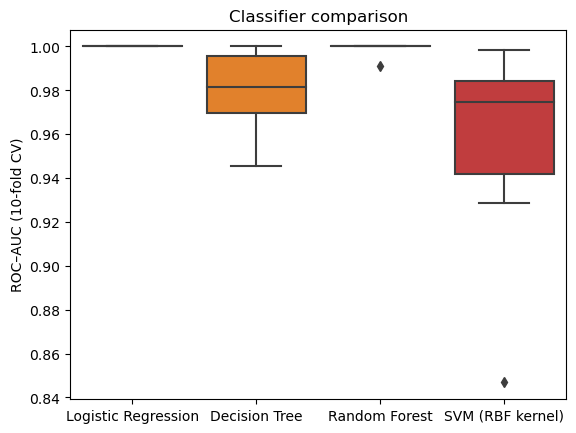

In [21]:
import matplotlib.pyplot as plt

results_df = pd.DataFrame(cv_results)

sns.boxplot(results_df)

plt.ylabel("ROC–AUC (10-fold CV)")
plt.title("Classifier comparison")
plt.show()


**Exercises**

1. Let's read a boxplot!

    1a. Reading the boxplots, what do the horizontal lines in the middle of each box mean?

    1b. What does the height of each box (how long it is) mean? 
    
    1c. What about the whiskers (the "T" at the end of a box)?
    
    1d. What about the points beyond the whiskers?
    
    1e. What does it mean when a box is super thin, and you see almost no box at all?

2. What patterns do you see comparing one classifier model to another?

3. Which models are most consistent across folds?

4. How could you further validate these findings?